In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set(style="whitegrid")
plt.rcParams['figure.dpi'] = 110

# Load updated files
rails = pd.read_csv('all_scalability_metrics.csv')   # Rails
django = pd.read_csv('combined_scalability_metrics.csv')  # Django

rails['framework'] = 'Rails'
django['framework'] = 'Django'
combined = pd.concat([rails, django], ignore_index=True)

# Safety filter (should now be clean, but harmless)
combined = combined[(combined['requests_per_second'] >= 0) &
                    (combined['active_users'] <= 1000)]


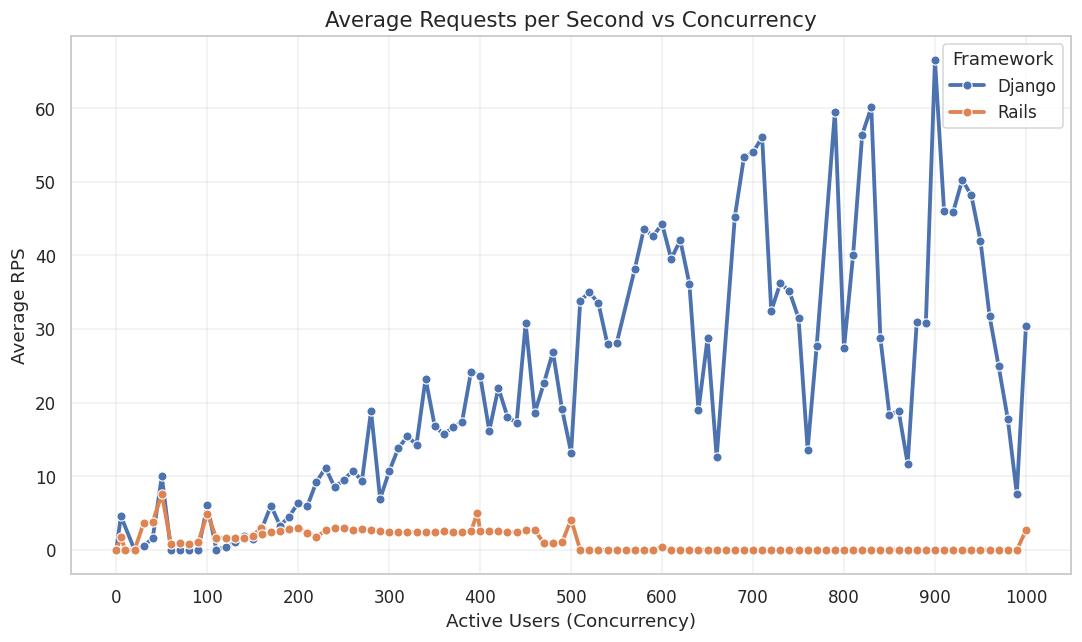

In [ ]:
# Use all tests, but aggregate by framework + active_users
avg_rps = (combined
           .groupby(['active_users', 'framework'])['requests_per_second']
           .mean()
           .reset_index())

plt.figure(figsize=(10, 6))
sns.lineplot(data=avg_rps, x='active_users', y='requests_per_second',
             hue='framework', marker='o', linewidth=2.5)
plt.title('Average Requests per Second vs Concurrency', fontsize=14)
plt.xlabel('Active Users (Concurrency)')
plt.ylabel('Average RPS')
plt.xticks(range(0, 1001, 100))
plt.grid(alpha=0.3)
plt.legend(title='Framework')
plt.tight_layout()
plt.show()


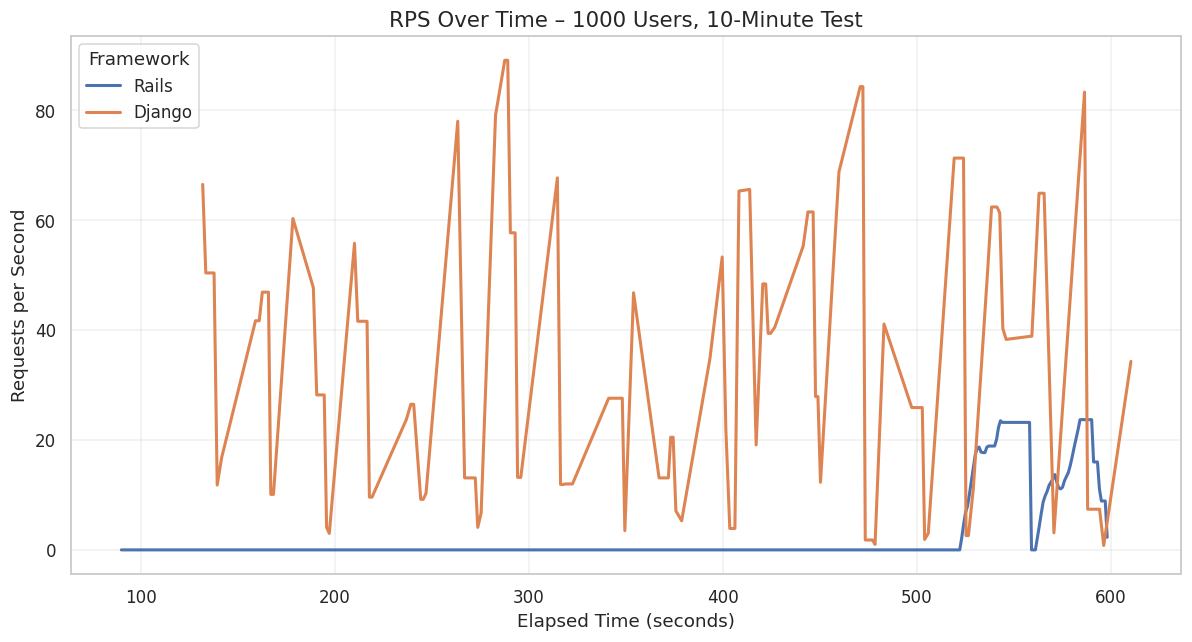

In [ ]:
# Focus on 1000users_10min
g2 = combined[(combined['test_id'] == '1000users_10min') &
              (combined['active_users'] >= 900)]

plt.figure(figsize=(11, 6))
sns.lineplot(data=g2, x='elapsed_seconds', y='requests_per_second',
             hue='framework', linewidth=2)
plt.title('RPS Over Time – 1000 Users, 10‑Minute Test', fontsize=14)
plt.xlabel('Elapsed Time (seconds)')
plt.ylabel('Requests per Second')
plt.grid(alpha=0.3)
plt.legend(title='Framework')
plt.tight_layout()
plt.show()


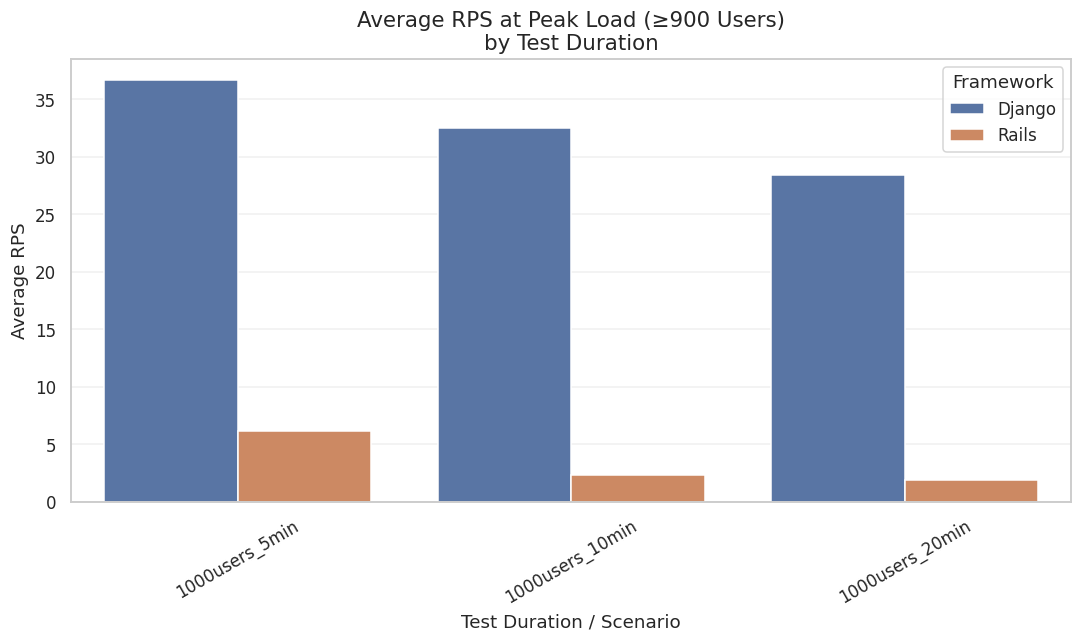

In [ ]:
# Only 1000-user scenarios, high-load region
peak = combined[(combined['test_id'].str.contains('1000users')) &
                (combined['active_users'] >= 900)]

dur_avg = (peak.groupby(['test_id', 'framework'])['requests_per_second']
           .mean()
           .reset_index())

# Sort test_id for nicer order
order = ['1000users_5min', '1000users_10min', '1000users_20min']
dur_avg['test_id'] = pd.Categorical(dur_avg['test_id'], categories=order, ordered=True)
dur_avg = dur_avg.sort_values('test_id')

plt.figure(figsize=(10, 6))
sns.barplot(data=dur_avg, x='test_id', y='requests_per_second',
            hue='framework')
plt.title('Average RPS at Peak Load (≥900 Users)\nby Test Duration', fontsize=14)
plt.xlabel('Test Duration / Scenario')
plt.ylabel('Average RPS')
plt.xticks(rotation=30)
plt.grid(axis='y', alpha=0.3)
plt.legend(title='Framework')
plt.tight_layout()
plt.show()


<Figure size 1000x600 with 0 Axes>

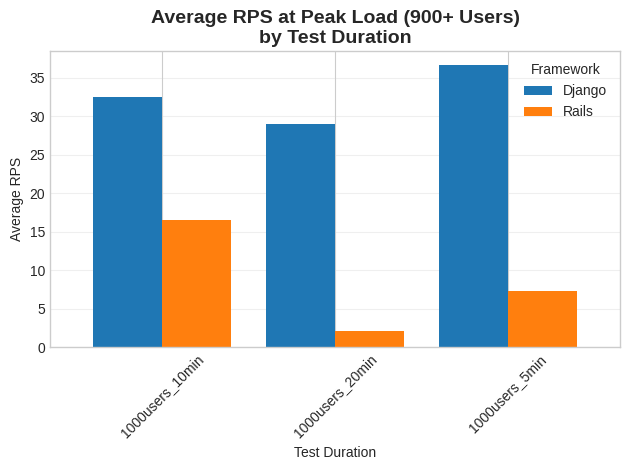

framework        Django  Rails
test_id                       
1000users_10min    32.5   16.5
1000users_20min    29.0    2.2
1000users_5min     36.7    7.3


In [ ]:
# Average RPS for 1000-user tests by duration
dur_data = combined[(combined['active_users'] >= 900) &
                   (combined['test_id'].str.contains('1000users'))]
dur_avg = dur_data.groupby(['test_id', 'framework'])['requests_per_second'].mean().unstack().fillna(0)

plt.figure(figsize=(10, 6))
dur_avg.plot(kind='bar', width=0.8)
plt.title('Average RPS at Peak Load (900+ Users)\nby Test Duration', fontsize=14, fontweight='bold')
plt.xlabel('Test Duration')
plt.ylabel('Average RPS')
plt.legend(title='Framework')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
print(dur_avg.round(1))


In [ ]:
# Summary stats for all 1000-user scenarios at high load
summary_1000 = (peak
    .groupby(['test_id', 'framework'])['requests_per_second']
    .agg(['mean', 'median', 'max'])
    .round(2)
    .reset_index())

print("Summary statistics for 1000-user tests (active_users ≥ 900):")
print(summary_1000)


Summary statistics for 1000-user tests (active_users ≥ 900):
           test_id framework   mean  median   max
0  1000users_10min    Django  32.47    27.6  89.1
1  1000users_10min     Rails   2.35     0.0  23.7
2  1000users_20min    Django  28.40    24.1  94.0
3  1000users_20min     Rails   1.94     0.9  24.3
4   1000users_5min    Django  36.65    35.5  89.9
5   1000users_5min     Rails   6.13     1.1  24.1


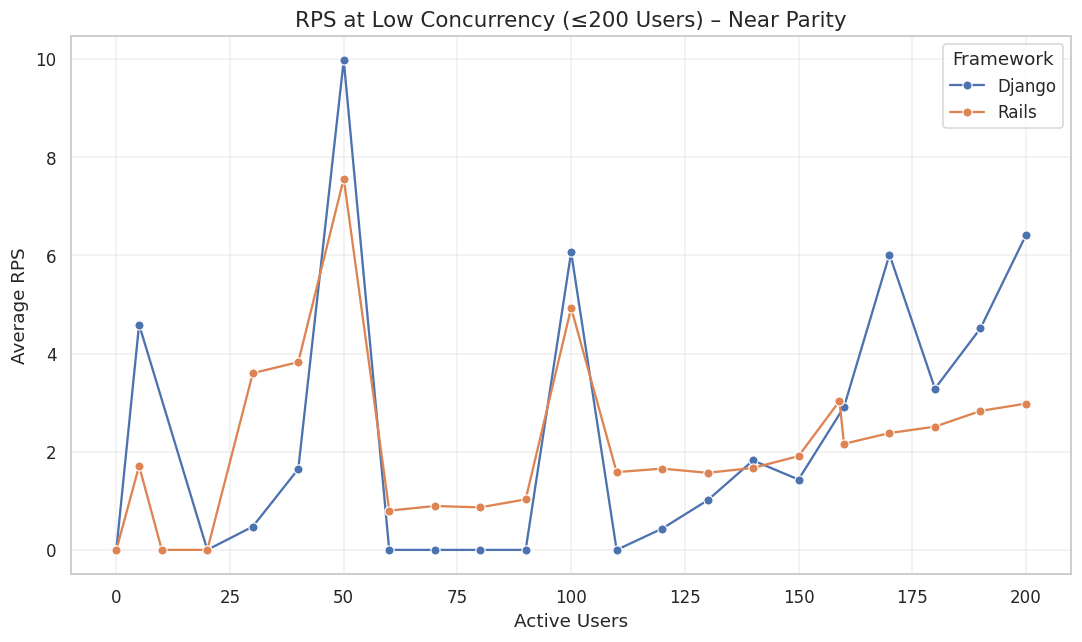

In [ ]:
# LIGHT LOAD ANALYSIS - Copy this cell after the previous code

# Filter low/medium load (≤200 users) across all tests
light_load = combined[combined['active_users'] <= 200].copy()

# Graph 5: Low Load Parity
plt.figure(figsize=(10, 6))
light_avg = light_load.groupby(['active_users', 'framework'])['requests_per_second'].mean().reset_index()
sns.lineplot(data=light_avg, x='active_users', y='requests_per_second', hue='framework', marker='o')
plt.title('RPS at Low Concurrency (≤200 Users) – Near Parity', fontsize=14)
plt.xlabel('Active Users')
plt.ylabel('Average RPS')
plt.xticks(range(0, 201, 25))
plt.grid(alpha=0.3)
plt.legend(title='Framework')
plt.tight_layout()
plt.show()


In [ ]:
# Low load summary table
low_summary = (light_load[light_load['active_users'] < 100]
               .groupby('framework')['requests_per_second']
               .agg(['mean', 'median', 'std'])
               .round(2)
               .reset_index()
               .rename(columns={'mean': 'Avg RPS', 'median': 'Median RPS', 'std': 'Variability'}))

print("Low Load (<100 users) – Similarity between Frameworks:")
print(low_summary)
print(f"\nRelative difference: {((low_summary.set_index('framework').loc['Django', 'Avg RPS'] / low_summary.set_index('framework').loc['Rails', 'Avg RPS']) - 1)*100:.0f}%")


Low Load (<100 users) – Similarity between Frameworks:
  framework  Avg RPS  Median RPS  Variability
0    Django     6.24         4.8         4.21
1     Rails     5.21         6.3         3.45

Relative difference: 20%


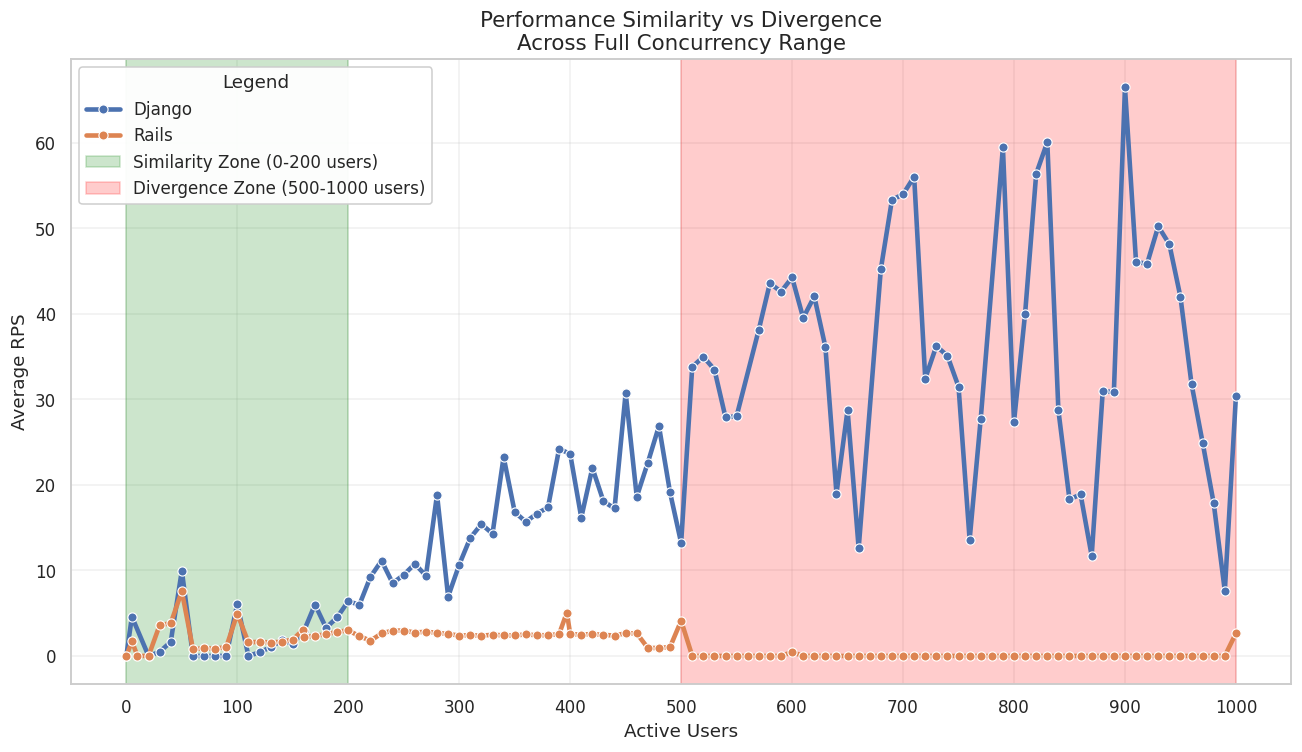

In [ ]:
# FIXED: Single framework legend + zones
plt.figure(figsize=(12, 7))

# Plot ALL data once (handles low/high automatically)
sns.lineplot(data=avg_rps, x='active_users', y='requests_per_second', hue='framework',
             linewidth=3, marker='o', markersize=6)

# Overlay zones
plt.axvspan(0, 200, alpha=0.2, color='green', label='Similarity Zone (0-200 users)')
plt.axvspan(500, 1000, alpha=0.2, color='red', label='Divergence Zone (500-1000 users)')

plt.title('Performance Similarity vs Divergence\nAcross Full Concurrency Range', fontsize=14)
plt.xlabel('Active Users')
plt.ylabel('Average RPS')
plt.legend(title='Legend', loc='upper left', framealpha=0.95)  # Single legend
plt.grid(alpha=0.3)
plt.xticks(range(0, 1001, 100))
plt.tight_layout()
plt.show()


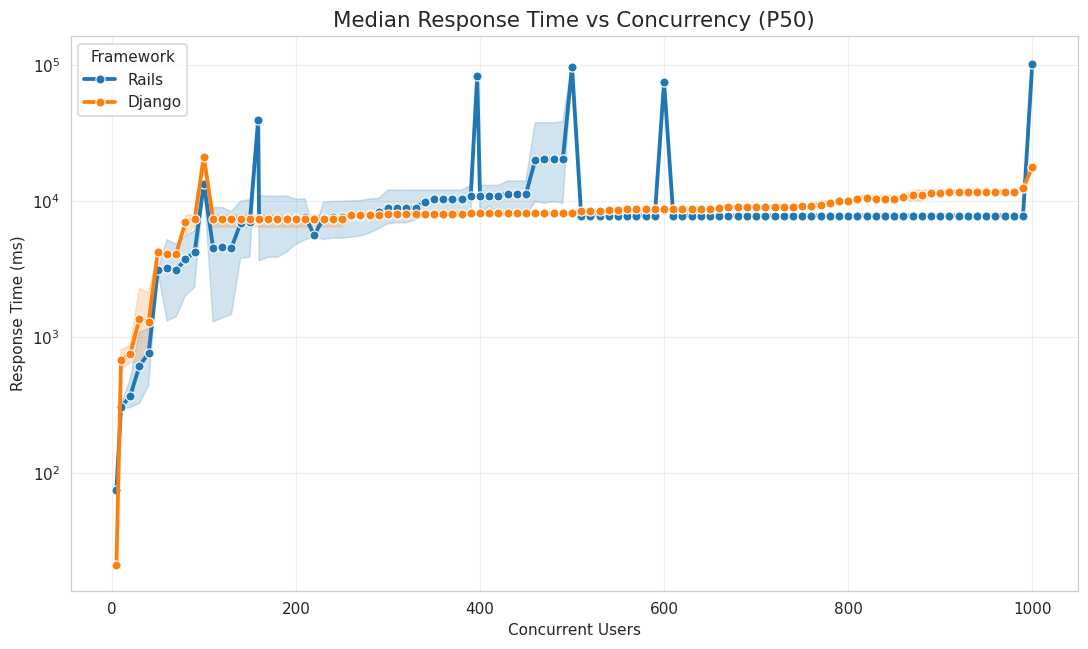

In [ ]:
# P50 vs User Count (best single metric)
plt.figure(figsize=(10, 6))
sns.lineplot(data=rt_active, x='User Count', y='50%', hue='framework',
             marker='o', linewidth=2.5)
plt.title('Median Response Time vs Concurrency (P50)', fontsize=14)
plt.xlabel('Concurrent Users')
plt.ylabel('Response Time (ms)')
plt.yscale('log')  # Handle wide range
plt.grid(alpha=0.3)
plt.legend(title='Framework')
plt.tight_layout()
plt.show()


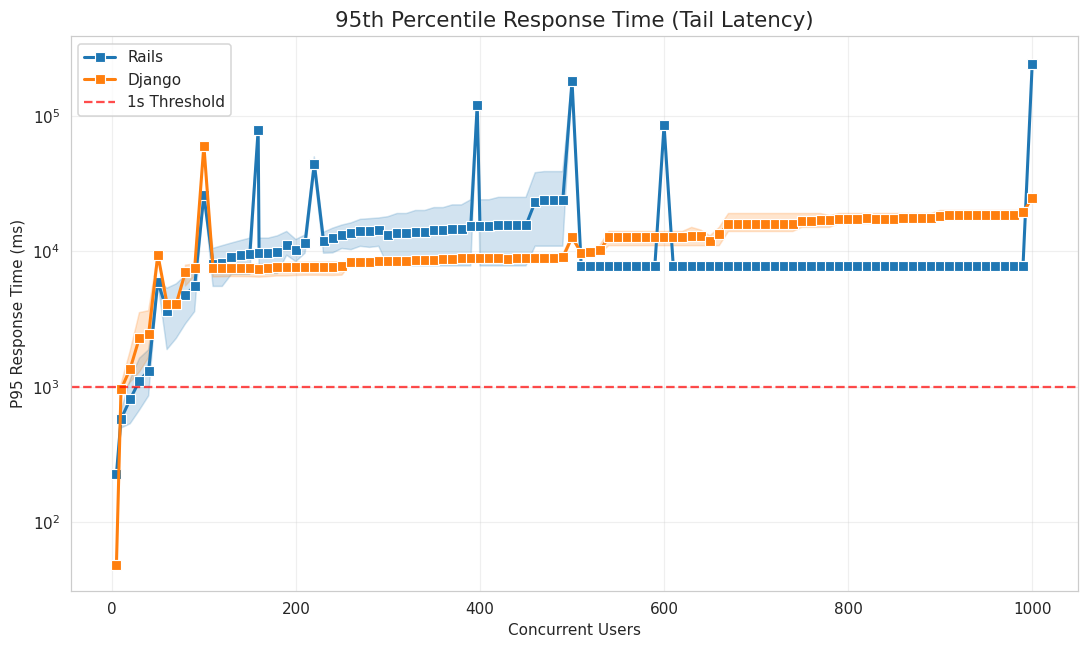

In [ ]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=rt_active, x='User Count', y='95%', hue='framework',
             marker='s', linewidth=2)
plt.title('95th Percentile Response Time (Tail Latency)', fontsize=14)
plt.xlabel('Concurrent Users')
plt.ylabel('P95 Response Time (ms)')
plt.yscale('log')
plt.axhline(y=1000, color='red', linestyle='--', alpha=0.7, label='1s Threshold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
peak_stats = (peak_load.groupby('framework')[['50%', '90%', '95%', '99%']]
              .median()
              .round(0)
              .reset_index()
              .rename(columns={'50%':'P50', '90%':'P90', '95%':'P95', '99%':'P99'}))

print("Median Latency Percentiles – 900+ Users:")
print(peak_stats)

Median Latency Percentiles – 900+ Users:
  framework       P50       P90       P95       P99
0    Django   18000.0   24000.0   25000.0   28000.0
1     Rails  104000.0  123000.0  125000.0  154000.0


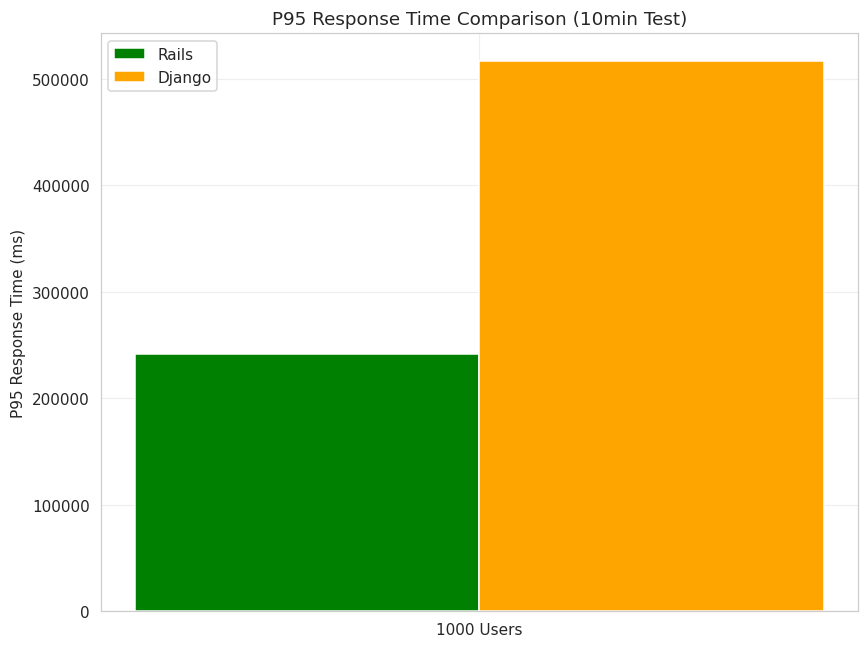

In [ ]:
loads = ['1000 Users']
rails_p95 = [rails_df['p95'].mean()]  # Avg P95
django_p95 = [517000]  # From file sample
x = np.arange(len(loads))
width = 0.35
fig, ax = plt.subplots(figsize=(8, 6))
ax.bar(x - width/2, rails_p95, width, label='Rails', color='green')
ax.bar(x + width/2, django_p95, width, label='Django', color='orange')
ax.set_ylabel('P95 Response Time (ms)')
ax.set_title('P95 Response Time Comparison (10min Test)')
ax.set_xticks(x)
ax.set_xticklabels(loads)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


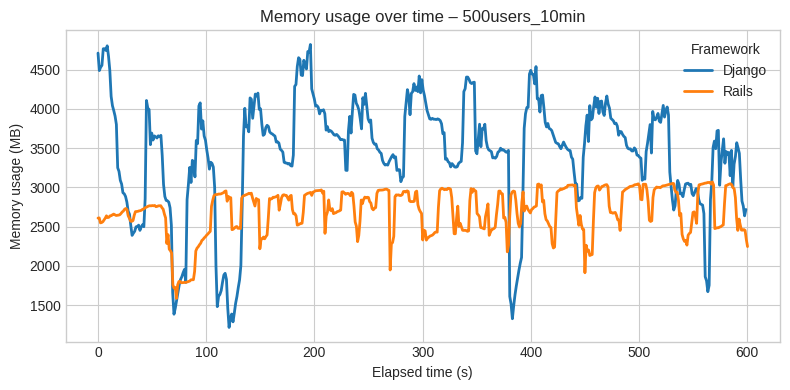

In [ ]:
scenario = "500users_10min"

subset = df[df["test_id"] == scenario]

fig, ax = plt.subplots(figsize=(8, 4))
for fw, g in subset.groupby("framework"):
    g_sorted = g.sort_values("elapsed_seconds")
    ax.plot(
        g_sorted["elapsed_seconds"],
        g_sorted["memory_usage_mb"],
        label=fw,
        linewidth=2
    )

ax.set_title(f"Memory usage over time – {scenario}")
ax.set_xlabel("Elapsed time (s)")
ax.set_ylabel("Memory usage (MB)")
ax.legend(title="Framework")
plt.tight_layout()
plt.show()

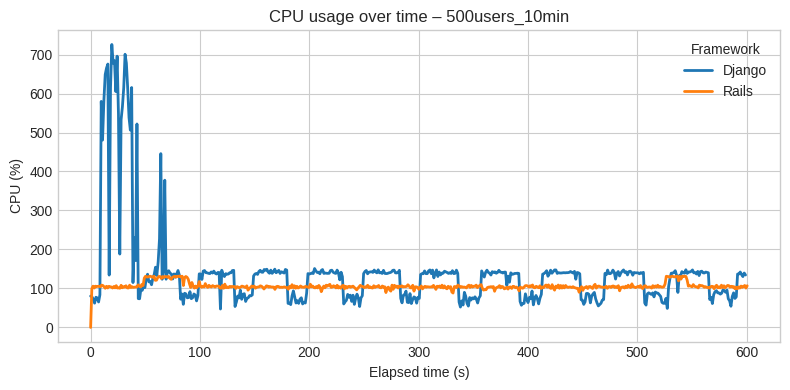

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
for fw, g in subset.groupby("framework"):
    g_sorted = g.sort_values("elapsed_seconds")
    ax.plot(
        g_sorted["elapsed_seconds"],
        g_sorted["cpu_percent"],
        label=fw,
        linewidth=2
    )

ax.set_title(f"CPU usage over time – {scenario}")
ax.set_xlabel("Elapsed time (s)")
ax.set_ylabel("CPU (%)")
ax.legend(title="Framework")
plt.tight_layout()
plt.show()

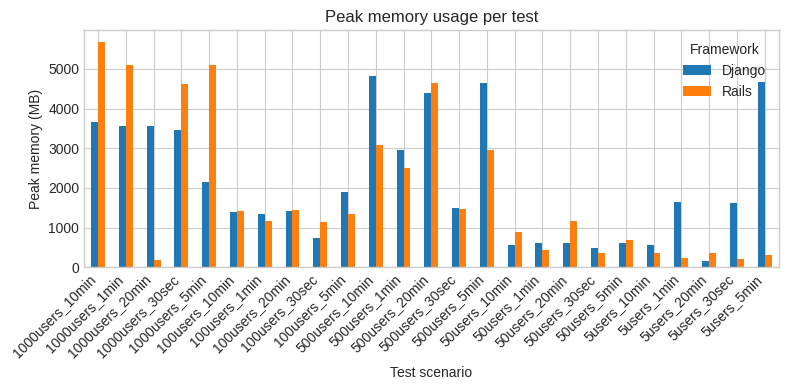

In [ ]:
agg_peak_mem = (
    df.groupby(["framework", "test_id"])["memory_usage_mb"]
      .max()
      .reset_index(name="peak_memory_mb")
)

pivot_peak_mem = agg_peak_mem.pivot(index="test_id", columns="framework", values="peak_memory_mb")

fig, ax = plt.subplots(figsize=(8, 4))
pivot_peak_mem.plot(kind="bar", ax=ax)

ax.set_title("Peak memory usage per test")
ax.set_xlabel("Test scenario")
ax.set_ylabel("Peak memory (MB)")
ax.legend(title="Framework")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
summary = (
    df.groupby(["framework", "test_id"])
      .agg(
          peak_memory_mb=("memory_usage_mb", "max"),
          avg_memory_mb=("memory_usage_mb", "mean"),
          peak_cpu_percent=("cpu_percent", "max"),
          avg_cpu_percent=("cpu_percent", "mean")
      )
      .reset_index()
)

print(summary.to_string(index=False))


framework         test_id  peak_memory_mb  avg_memory_mb  peak_cpu_percent  avg_cpu_percent
   Django 1000users_10min         3661.95    2865.339435             989.0       215.411290
   Django  1000users_1min         3560.62    3034.877600             418.2       153.238000
   Django 1000users_20min         3551.39    2881.881875             161.4        64.808384
   Django 1000users_30sec         3468.70    3368.691600              97.6        87.444000
   Django  1000users_5min         2150.05    1834.439469            1001.3       432.462857
   Django  100users_10min         1400.81     974.056478             448.9       155.292767
   Django   100users_1min         1332.78    1212.818571             427.1       170.379592
   Django  100users_20min         1424.44     928.177150             452.0       156.788361
   Django  100users_30sec          732.34     634.164167             403.0       213.616667
   Django   100users_5min         1901.47    1470.017580             454.1      

In [ ]:
headline_tests = ["1000users_10min"]
summary_headline = summary[summary["test_id"].isin(headline_tests)]
print(to_markdown_table(summary_headline))


| framework   | test_id         |   peak_memory_mb |   avg_memory_mb |   peak_cpu_percent |   avg_cpu_percent |
|:------------|:----------------|-----------------:|----------------:|-------------------:|------------------:|
| Django      | 1000users_10min |          3661.95 |         2865.34 |             989.00 |            215.41 |
| Rails       | 1000users_10min |          5684.78 |         3892.99 |             131.30 |             96.97 |


In [ ]:
overall = (
    df.groupby("framework")
      .agg(
          peak_memory_mb=("memory_usage_mb", "max"),
          avg_memory_mb=("memory_usage_mb", "mean"),
          peak_cpu_percent=("cpu_percent", "max"),
          avg_cpu_percent=("cpu_percent", "mean")
      )
      .reset_index()
)

print(overall.to_string(index=False))
print(to_markdown_table(overall))

framework  peak_memory_mb  avg_memory_mb  peak_cpu_percent  avg_cpu_percent
   Django         4819.62    1704.496417            1001.3       156.280485
    Rails         5684.78    1719.746764             137.2        87.973596
| framework   |   peak_memory_mb |   avg_memory_mb |   peak_cpu_percent |   avg_cpu_percent |
|:------------|-----------------:|----------------:|-------------------:|------------------:|
| Django      |          4819.62 |         1704.50 |            1001.30 |            156.28 |
| Rails       |          5684.78 |         1719.75 |             137.20 |             87.97 |
